# Soybean weather-signal strategy: research suite

**Instrument:** `ZS=F`, CBOT soybean futures, Yahoo Finance continuous front-month series, quoted in cents per bushel.
**Strategy:** the frozen spec `SOY_JULAUG_PCT80_v1` (`soybean/spec/SOY_JULAUG_PCT80_v1.md`).

> **Status: no edge demonstrated.** On the saved run, the full-history Sharpe is +0.35. Its bootstrap 95% interval includes zero, and it does not survive a correction for the 47 configurations tried (deflated Sharpe 0.27). The holdout looks strong (Sharpe +1.81, 10 episodes, 90% win rate), but that holdout was already seen during development, so it is not a clean test. The clean test is the forward window that starts 2027-07-01 (`soybean/spec/FORWARD_PROTOCOL.md`).

## How to run this notebook

1. `pip install -r requirements.txt` (this includes Jupyter).
2. Open the notebook from anywhere inside the repository and choose **Run All**.
3. `MODE = "saved"` (the default) works offline. It loads the committed run and takes about a minute.
4. `MODE = "rerun"` recomputes everything from raw data by calling the engine. It needs internet on the first run. The engine takes about 15 seconds per run with a warm cache. A cold cache is slower, because NASA POWER is paced at one request per second.

Nothing in this notebook writes to the trial log, the spec files, or the saved results.

## Contents

1. Key terms
2. The question and the economic rationale
3. Behavioural edge: which part of the market, and who is on the other side
4. Data sources and citations
5. The strategy, as frozen
6. Backtesting: how the engine works and how this notebook loads it
7. Results: performance, equity curve, positions, episodes
8. Costs: basis points per trade and why we use them
9. Statistical testing
10. Parameter sensitivity (in-sample)
11. Verdict and forward test
12. Caveats and known limitations
13. References

## 1. Key terms

| Term | Meaning in this notebook |
|---|---|
| **Ticker `ZS=F`** | CBOT soybean futures, Yahoo Finance code. A continuous front-month series, so it rolls between contracts without adjustment. |
| **Contract** | CME soybean futures: 5,000 bushels, quoted in cents per bushel. The minimum tick is ¼ cent = $12.50 per contract. |
| **Position** | Fraction of equity exposed to the futures return. `+0.5` is long with 50% of equity at risk; `-0.5` is short. |
| **Equity / portfolio value** | Starting capital plus cumulative net P&L. The engine starts at $1,000,000. |
| **Net return** | Daily return after transaction costs. This is the series the Sharpe ratio uses. |
| **P&L** | Profit and loss in dollars. *Gross* P&L is before costs. *Net* P&L is after costs. |
| **bp (basis point)** | 1 bp = 0.01% = 0.0001. Costs here are charged in bps of equity per unit of position traded. |
| **Half-spread** | Half the bid-ask spread. Paid each time you trade, on top of commissions. |
| **Turnover** | Total size of position changes divided by equity, per year. A 0.5 position opened and closed is 1.0 turned over. |
| **Episode (trade)** | A continuous run of one position sign, from entry to exit. A flip from long to short is a new episode. |
| **Win rate** | Share of episodes with positive net P&L. |
| **Profit factor** | Gross profit of winning episodes divided by gross loss of losing episodes. Above 1 is profitable. |
| **Sharpe ratio** | Mean daily net return divided by its standard deviation, times √252. Risk-free rate taken as zero. |
| **Sortino ratio** | As Sharpe, but the denominator is downside deviation (negative returns only). |
| **Max drawdown** | Largest peak-to-trough fall in portfolio value. |
| **CAGR** | Compound annual growth rate of portfolio value. |
| **Calmar ratio** | CAGR divided by the absolute max drawdown. |
| **Equity curve** | Portfolio value over time, shown as cumulative return. |
| **Benchmark** | A simple alternative to compare against. Here, buy-and-hold `ZS=F` in July and August only, fully invested. |
| **In-sample** | Data used to choose settings. Here, every date before 2025-06-01. |
| **Out-of-sample (holdout)** | Dates held back from development. Here, 2025-06-01 onward. It was already seen during development, so it is not clean. |
| **Walk-forward** | A backtest that at each date uses only data available up to that date, and refits as it goes. |
| **Look-ahead bias** | Using information that was not yet known on the trading date. The engine lags features and fills trades at the next close. |
| **Pre-registration** | Writing the rule, the periods and the pass/fail criteria down before running the test. |
| **Multiple testing** | Trying many configurations makes a good result likely by chance. Corrected here with the deflated Sharpe ratio. |
| **Probabilistic Sharpe ratio (PSR)** | Probability that the true Sharpe is above a benchmark, allowing for sample length, skew and kurtosis. |
| **Deflated Sharpe ratio (DSR)** | PSR after raising the benchmark to the expected best Sharpe from N trials with no skill. |
| **Block bootstrap** | Resamples contiguous 21-session blocks, so autocorrelation in returns is kept. |
| **Permutation test** | Shifts the position series against the returns many times to see whether timing beats chance. |
| **p-value** | Probability of a result at least this extreme if the null hypothesis were true. |
| **Confidence interval (CI)** | Range that would contain the true value in about 95% of repeated samples. |
| **Wilson interval** | Confidence interval for a proportion, such as a win rate, that behaves well with small samples. |
| **Spearman rank correlation** | Correlation of ranks. Measures whether the forecast orders the outcomes correctly, not whether its size is right. |
| **Stress indicator** | Weather flag or z-score for heat above 35 °C, cold below 15 °C, or a dry 7-day spell under 30 mm. |
| **Z-score** | Value minus its historical mean, divided by its historical standard deviation. |
| **ONI** | Oceanic Niño Index. Positive values mean El Niño, negative values mean La Niña. |
| **R3–R6** | Soybean reproductive growth stages from early pod set to full seed. |

## 2. The question and the economic rationale

**Question.** Does daily weather stress in the main U.S. soybean states, during the reproductive stages of the crop, predict the return of `ZS=F` over the next 10 sessions?

**Mechanism under test (H1).** Weather stress lowers expected yield, which lowers expected supply, which raises the futures price. The strategy aims to trade the price response before it fully reflects the damage.

**Why this window.** Yield is most sensitive to stress during pod set and seed fill (R3–R6), which fall in roughly July and August across the Corn Belt. The engine watches for heat above 35 °C, cold below 15 °C, and dry spells under 30 mm in 7 days.

**Why the market might already price it.** Weather forecasts and crop-condition reports are public and widely followed. If expected damage is already in the price, there is little left to trade after the fact. This is a standard efficient-markets objection, and the tests in section 9 are designed to check it.

**Null hypothesis.** Weather-based forecasts carry no information about the next 10 sessions' return. Any P&L is then noise plus costs.

**What the economic story does and does not fix.** The story predicts that stress should be followed by higher prices. The model does not impose that sign. Ridge regression learns the direction from data, and the traded signal is a z-score of the forecast against its recent history. So the sign is a finding, not an assumption.

## 3. Behavioural edge: which part of the market, and who is on the other side

A trading edge needs a reason the price is wrong, and a reason the wrong price persists. The table lists the candidate mechanisms for this strategy. Each one names who would be on the other side and what it predicts, so each can be tested.

| # | Hypothesis | Mechanism | Who is on the other side | What it predicts | What the suite finds |
|---|---|---|---|---|---|
| **H1** | Slow price response to weather stress (underreaction) | Yield information arrives in pieces: daily weather, forecasts, USDA reports. Investors update gradually, so prices drift after a stress signal (Hong & Stein, 1999). | Participants who react to reports rather than to daily weather | Drift in the direction of the learned signal, over about 10 sessions | Timing carries information before costs (permutation p = 0.028, full history). Forecast rank skill is not significant (Spearman −0.04, p = 0.20). |
| **H2** | Attention-driven overreaction to weather headlines | Heat headlines draw retail and speculative attention (Barber & Odean, 2008). Prices overshoot, then partly revert. | Liquidity providers who fade headline moves | Reversal after a headline spike | Not tested separately. The signal can go either way, so this needs its own test before it can be claimed. |
| **H3** | Seasonal hedging-pressure premium | Producers sell futures into harvest. Speculators who take the other side may earn a risk premium (Keynes, 1930; Bessembinder, 1992). | Commercial hedgers | A long bias in July–August, regardless of weather | The simple in-season buy-and-hold has a Sharpe of −0.46 over full history, so there is no long-bias premium in that form. |

**Where an edge would sit, if one exists.** It would sit in the July–August part of the soybean futures market, when yield uncertainty is highest, when weather headlines draw the most attention, and when many participants respond to reports rather than daily data. Those are the three conditions that would make H1 or H2 plausible.

**What this notebook can and cannot say.** It can show whether timing inside the window carries information (section 9). It cannot show the mechanism. Nothing here separates H1 from H2 or from pure chance, so treat the mechanism as a hypothesis.

## 4. Data sources and citations

Full references are in section 13.

| Data | Provider and citation | Access in this repo | Used for |
|---|---|---|---|
| `ZS=F` soybean futures, daily | Yahoo Finance, via the `yfinance` library (Aroussi) | `soyweather/data/futures_prices.py`; cache in `data_storage/raw/market/`; the close series used is saved to `soybean/results/inference/ZS_F_close_used.csv` | Returns, P&L, benchmark, price chart |
| `ZC=F` corn futures, daily | Yahoo Finance (as above) | Same client | The soybean ÷ corn price-ratio feature |
| Daily weather (`T2M`, `T2M_MAX`, `T2M_MIN`, `PRECTOTCORR`, and others), 0.5° grid | NASA POWER, Agroclimatology (AG) community. NASA Langley Research Center POWER Project (`power.larc.nasa.gov`) | `soyweather/data/nasa_power.py`; cache in `data_storage/raw/climate/` | Stress indicators |
| Oceanic Niño Index (ONI) | NOAA Climate Prediction Center, `oni.ascii.txt` | `soyweather/data/enso.py`; cache in `data_storage/raw/enso/`. Each value is only used two months after its centre month, to avoid look-ahead. | ENSO feature |
| Region production weights | Approximate production shares set in `soyweather/regions.py`. The repo does not record a source. | Iowa 0.30, Illinois 0.30, Minnesota 0.20, Indiana 0.20 | Regional weighting |
| Contract specification (5,000 bu, ¼ cent tick) | CME Group, soybean futures contract specifications | Not in repo; cited for the cost arithmetic in section 8 | Cost justification |
| USDA NASS yield and crop condition | USDA NASS QuickStats API | `soyweather/data/usda_nass.py`. **Not used by the frozen spec.** Only used by other tests. | Context only |

**Price units.** Prices are in cents per bushel. A move from 1,000 to 1,010 is a 1% return.

## 5. The strategy, as frozen

The spec was set down in `soybean/spec/SOY_JULAUG_PCT80_v1.md`. The code and the notebook use the same values. Section 6 prints them from the live settings to confirm this.

**Signal pipeline (each step uses only information available that day):**

1. **Seasonal z-scores.** Each weather variable is standardised against the same calendar day in earlier years. The statistics are shifted one year, which prevents look-ahead.
2. **Stress indicators.** Heat, cold and dryness flags and z-scores, summed over trailing 7, 14 and 30 days.
3. **Production-weighted aggregation.** Stress is averaged across the four states using the weights in section 4.
4. **Soybean extras.** Soybean ÷ corn price ratio and ENSO (ONI), each with 7, 14 and 30-day rolling means. Cloud, soil-moisture and disease features are off.
5. **Feature selection.** Keep at most 15 features, ranked by correlation with the target in the training window.
6. **Forecast.** Ridge regression (α = 1), with PCA keeping 95% of variance. Target: the 10-session forward return. Trained on a 3-year window, refit monthly.
7. **Direction classifier and veto.** A logistic regression predicts the sign. If it disagrees with the Ridge forecast and is more than 65% confident, the signal is set to zero.
8. **Signal.** The forecast is z-scored against its last 60 values and clipped to ±3.
9. **Position.** Long 50% of equity when the signal is strong enough and positive, short 50% when negative. Positions are filled at the next session's close.
10. **Filters and risk.** Trade only in July and August. Skip signals when 20-day volatility is in the top 20% of its trailing year. Close after a 5% loss from entry. Flatten on the first day outside the season.

**Pass / fail rule, fixed in the spec.**
- **Pass** only if, on the holdout at 10 bps: net Sharpe > 0, max drawdown no worse than −25%, and at least 10 independent episodes. A **robust pass** also needs net Sharpe > 0 at 25 bps.
- **Fail** rejects the spec. It does not justify changing settings and retesting on the same holdout.

In [1]:
import os, sys, io, contextlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.width", 140)


def find_repo_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "soyweather").is_dir() and (p / "soybean").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the repository (the folder that holds soyweather/ and soybean/).")


ROOT = find_repo_root()
os.chdir(ROOT)                       # the engine and the saved files use repo-relative paths
sys.path.insert(0, str(ROOT))

# Pin the frozen-spec settings before the engine reads them. These are the same pins as
# soybean/experiments/regression_check.py, so a local .env file cannot change the numbers.
os.environ.update({"TRAIN_WINDOW_YEARS": "3", "FIXED_POSITION_SIZE": "0.5", "MIN_SIGNAL_STRENGTH": "0.01",
                   "TARGET_PORTFOLIO_VOL": "0.99", "MAX_SINGLE_POSITION": "1.0", "STRATEGY_MODE": "directional",
                   "TRANSACTION_COST_BPS": "10", "ONLY_TRADE_GROWING_SEASON": "true"})

from soyweather import settings as s
from soyweather import simulation as eng
from soyweather.simulation import run_backtest, POSITION_FILTERS, EXECUTION_ASSUMPTIONS
from soyweather.features.soybean_extras import SOYBEAN_FEATURE_SWITCHES
from soyweather.data.futures_prices import FuturesPriceClient
from loguru import logger

logger.remove()
logger.add(sys.stderr, level="WARNING")     # the engine logs every step at INFO; keep the notebook readable

TICKER = "ZS=F"
START, END = "2000-01-01", "2026-10-02"
HOLD_START = pd.Timestamp("2025-06-01")     # out-of-sample window in the spec
N_TRIALS = 47                                # configurations tried, from soybean/spec/trial_log.md
BLOCK, DRAWS, PERMS, SEED = 21, 5000, 5000, 0
EULER_GAMMA = 0.5772156649

# Frozen spec SOY_JULAUG_PCT80_v1
s.COMMODITY_TRADE_MONTHS["soybeans"] = [7, 8]
s.COMMODITY_VOL_THRESHOLDS["soybeans"] = 10.0          # fixed volatility cap disabled
POSITION_FILTERS.update({"vol_percentile_hi": 0.80, "trend_sma": None, "stop_loss_pct": 0.05})
assert SOYBEAN_FEATURE_SWITCHES["price_ratio"] and SOYBEAN_FEATURE_SWITCHES["enso"]
assert not any(SOYBEAN_FEATURE_SWITCHES[k] for k in ["cloud", "soil_moisture", "disease"])

# ---- choose how to get the numbers ----
MODE = "saved"            # "saved": offline, loads the committed run.   "rerun": calls the engine on fresh data.
RUN_SENSITIVITY = False   # rerun mode only: 20 more engine runs, several minutes

half_spread = EXECUTION_ASSUMPTIONS["half_spread_bps"]["soybeans"]
frozen = pd.DataFrame({
    "Setting": ["Commodity", "Trade months", "Volatility filter", "Fixed volatility cap", "Trend filter",
                "Stop-loss", "Price-ratio feature", "ENSO feature", "Base transaction cost (bps)",
                "Half-spread (bps, soybeans)", "All-in cost per unit traded (bps)", "Position size (fraction of equity)",
                "Forward return horizon (sessions)", "Training window (years)", "Max features", "Starting capital ($)"],
    "Value": [TICKER, str(s.COMMODITY_TRADE_MONTHS["soybeans"]),
              f"{POSITION_FILTERS['vol_percentile_hi']:.0%} percentile of trailing year",
              s.COMMODITY_VOL_THRESHOLDS["soybeans"], str(POSITION_FILTERS["trend_sma"]),
              f"{POSITION_FILTERS['stop_loss_pct']:.0%}", SOYBEAN_FEATURE_SWITCHES["price_ratio"],
              SOYBEAN_FEATURE_SWITCHES["enso"], s.TRANSACTION_COST_BPS, half_spread,
              s.TRANSACTION_COST_BPS + half_spread, s.FIXED_POSITION_SIZE, s.FORWARD_RETURN_DAYS,
              s.TRAIN_WINDOW_YEARS, s.MAX_FEATURES, f"{s.INITIAL_CAPITAL:,.0f}"]})
print(f"Repo root: {ROOT}")
print(f"Ticker: {TICKER}    Mode: {MODE}")
frozen

Repo root: C:\Users\kkati\Kushagra\Projects\hackathons\soybeans_strategy
Ticker: ZS=F    Mode: saved


,Setting,Value
0,Commodity,ZS=F
1,Trade months,"[7, 8]"
2,Volatility filter,80% percentile of trailing year
3,Fixed volatility cap,10.0
4,Trend filter,None
5,Stop-loss,5%
6,Price-ratio feature,True
7,ENSO feature,True
8,Base transaction cost (bps),10.0
9,"Half-spread (bps, soybeans)",1.0


## 6. Backtesting: how the engine works and how this notebook loads it

The engine is `SoybeanBacktester` in `soyweather/simulation.py`. It is walk-forward:

- At each date it uses only data available up to that date.
- The Ridge model is refit once a month on the trailing 3-year window. Between refits it is reused.
- A signal computed at today's close is filled at tomorrow's close.
- Each trade costs `equity × |change in position| × (base bps + half-spread bps)`.

**Two ways to get the numbers.**

- **`saved`** loads `soybean/results/reference_frozen_exec2_full.csv`. This is the daily output of the frozen spec on the current engine, with the code defaults. It is what every statistic in this notebook is based on.
- **`rerun`** calls `run_backtest` again on the same date range and then checks the result against that saved file. If the check fails, the cause is usually fresh data from Yahoo or NASA, not the code.

In [2]:
REF = ROOT / "soybean/results/reference_frozen_exec2_full.csv"
CLOSE = ROOT / "soybean/results/inference/ZS_F_close_used.csv"


def prepare(raw, close):
    """Add the columns every calculation below uses. Positions and returns come from the engine."""
    d = raw.copy()
    if "date" in d.columns:
        d = d.set_index(pd.to_datetime(d["date"])).drop(columns="date")
    d.index = pd.to_datetime(d.index)
    d = d.sort_index()
    d["pos"] = d["soybeans_position"].fillna(0.0)                       # position held at the close
    d["pos_prev"] = d["pos"].shift(1).fillna(0.0)                       # position that earned the day's return
    d["px_ret"] = close.pct_change().reindex(d.index).fillna(0.0)       # ZS=F daily return
    d["net_ret"] = d["portfolio_return"].fillna(0.0)                    # net of costs (engine definition)
    d["traded"] = d["pos"].diff().abs().fillna(d["pos"].abs())          # |change in position|, x equity
    d["net_pnl"] = d["daily_pnl"] - d["transaction_costs"]              # $ net of costs
    d["in_season"] = d.index.month.isin([7, 8])
    return d


if MODE == "rerun":
    with contextlib.redirect_stdout(io.StringIO()):
        raw = run_backtest(START, END, ["soybeans"], s.INITIAL_CAPITAL)
    px = FuturesPriceClient().fetch_futures_data("soybeans", "N/A", "2000-01-01", END)
else:
    raw = pd.read_csv(REF, parse_dates=["date"])
    px = pd.read_csv(CLOSE, parse_dates=["date"])

close = px.assign(date=pd.to_datetime(px["date"])).set_index("date")["close"]   # cents per bushel
df = prepare(raw, close)

print(f"Rows: {len(df):,}   {df.index[0].date()} to {df.index[-1].date()}")
print(f"In-sample (before {HOLD_START.date()}): {(df.index < HOLD_START).sum():,} days")
print(f"Out-of-sample holdout (from {HOLD_START.date()}): {(df.index >= HOLD_START).sum():,} days")
print(f"{TICKER} close: {close.index[0].date()} to {close.index[-1].date()}, {len(close):,} sessions, cents per bushel")

Rows: 5,794   2003-09-24 to 2026-10-01
In-sample (before 2025-06-01): 5,458 days
Out-of-sample holdout (from 2025-06-01): 336 days
ZS=F close: 2000-09-15 to 2026-10-01, 6,550 sessions, cents per bushel


In [3]:
if MODE == "rerun":
    ref = pd.read_csv(REF, parse_dates=["date"]).set_index("date")
    cols = ["portfolio_value", "daily_pnl", "transaction_costs", "portfolio_return", "soybeans_position"]
    checks = pd.Series({c: bool(np.allclose(df[c].astype(float).values, ref[c].astype(float).values,
                                            rtol=1e-9, atol=1e-9)) for c in cols}, name="matches saved run")
    print(checks.to_string())
    if checks.all():
        print("\nThe engine reproduces the committed run exactly.")
    else:
        print("\nDifferences. Check whether Yahoo or NASA POWER data has changed since the saved run.")
else:
    print("Saved mode: the committed run is loaded as-is. Set MODE = 'rerun' to recompute it and check it against the reference.")

Saved mode: the committed run is loaded as-is. Set MODE = 'rerun' to recompute it and check it against the reference.


## 7. Results: performance, equity curve, positions, episodes

Performance is shown for three periods:

- **Full history**: every day in the saved run.
- **In-sample**: every day before 2025-06-01. This is the development period, the period the settings were chosen on.
- **Out-of-sample (holdout)**: 2025-06-01 onward. It was already seen during development, so read it as optimistic.

**Net** means after the 10 bps base cost and the 1 bp half-spread. Total return and drawdown use portfolio value. The README's +41.7% full-history figure compounds the engine's daily returns, which the README itself flags as an overstatement (section 12). This notebook does not use that compounding.

In [4]:
def episodes_detail(d):
    """Episodes = runs of one position sign. Same convention as soybean/experiments/inference_suite.py."""
    rows, cur, start, last, acc = [], None, None, None, 0.0
    for date, p, x in zip(d.index, d["pos"].values, d["net_pnl"].values):
        sg = np.sign(p)
        if cur is not None and sg != cur:
            rows.append(_episode_row(cur, start, last, acc, d)); cur, acc = None, 0.0
        if sg != 0:
            if cur is None:
                start = date
            cur, acc, last = sg, acc + x, date
        elif cur is not None:
            rows.append(_episode_row(cur, start, last, acc, d)); cur, acc = None, 0.0
    if cur is not None:
        rows.append(_episode_row(cur, start, last, acc, d))
    return pd.DataFrame(rows)


def _episode_row(sign, start, last, pnl, d):
    return {"side": "long" if sign > 0 else "short", "entry": pd.Timestamp(start), "exit": pd.Timestamp(last),
            "days_held": int((d.loc[start:last, "pos"] != 0).sum()), "net_pnl_usd": pnl}


def period_views(d):
    is_in = d.index < HOLD_START
    return {"Full history": (d, s.INITIAL_CAPITAL),
            "In-sample": (d[is_in], s.INITIAL_CAPITAL),
            "Out-of-sample (holdout)": (d[~is_in], d.loc[is_in, "portfolio_value"].iloc[-1])}


def performance(d, base_value):
    r = d["net_ret"].values
    n = len(r)
    years = n / 252
    value = np.r_[base_value, d["portfolio_value"].values]
    dd = value / np.maximum.accumulate(value) - 1
    sd = r.std(ddof=1)
    downside = np.sqrt(np.mean(np.minimum(r, 0.0) ** 2))
    cagr = (value[-1] / value[0]) ** (1 / years) - 1
    ep = episodes_detail(d)
    pnl = ep["net_pnl_usd"].to_numpy()
    costs = d["transaction_costs"].sum()
    traded_usd = (d["traded"].values * value[:-1]).sum()     # each trade is charged on the equity before it
    return {
        "Trading days": n,
        "Total return (value-based)": value[-1] / value[0] - 1,
        "Annualised return (CAGR)": cagr,
        "Annualised volatility": sd * np.sqrt(252),
        "Sharpe (net, annualised)": r.mean() / sd * np.sqrt(252),
        "Sortino (net, annualised)": r.mean() / downside * np.sqrt(252),
        "Max drawdown": dd.min(),
        "Calmar (CAGR / |max DD|)": cagr / abs(dd.min()),
        "Episodes (trades)": len(pnl),
        "Win rate (episodes)": (pnl > 0).mean(),
        "Average episode P&L ($)": pnl.mean(),
        "Profit factor": pnl[pnl > 0].sum() / -pnl[pnl < 0].sum(),
        "Net P&L ($)": d["net_pnl"].sum(),
        "Turnover (x equity per year)": d["traded"].sum() / years,
        "Costs ($)": costs,
        "Cost per unit traded, all changes (bps)": costs / traded_usd * 1e4,
        "Position changes with no cost (count)": int(((d["traded"] > 0) & (d["transaction_costs"] == 0)).sum()),
        "Cost per episode (bps of starting equity)": costs / len(pnl) / value[0] * 1e4,
        "Time in market (% of days)": (d["pos"] != 0).mean(),
    }


perf_table = pd.DataFrame({name: performance(dd, base) for name, (dd, base) in period_views(df).items()})

PCT = ["Total return (value-based)", "Annualised return (CAGR)", "Annualised volatility", "Max drawdown",
       "Win rate (episodes)", "Time in market (% of days)"]
USD = ["Average episode P&L ($)", "Net P&L ($)", "Costs ($)"]
BPS = ["Cost per unit traded, all changes (bps)", "Cost per episode (bps of starting equity)"]
COUNT = ["Trading days", "Episodes (trades)", "Position changes with no cost (count)"]


def fmt_cell(row, v):
    if row in PCT: return f"{v:.1%}"
    if row in USD: return f"${v:,.0f}"
    if row in BPS: return f"{v:.1f} bps"
    if row in COUNT: return f"{v:,.0f}"
    return f"{v:.2f}"


perf_fmt = pd.DataFrame({c: [fmt_cell(r, v) for r, v in perf_table[c].items()] for c in perf_table.columns},
                        index=perf_table.index)
print(f"Performance on {TICKER}, net of costs, 10 bps base + 1 bp half-spread")
perf_fmt

Performance on ZS=F, net of costs, 10 bps base + 1 bp half-spread


,Full history,In-sample,Out-of-sample (holdout)
Trading days,"5,794","5,458",336
Total return (value-based),34.9%,23.0%,9.7%
Annualised return (CAGR),1.3%,1.0%,7.2%
Annualised volatility,4.7%,4.7%,4.0%
"Sharpe (net, annualised)",0.35,0.27,1.81
"Sortino (net, annualised)",0.60,0.46,4.07
Max drawdown,-15.1%,-15.1%,-2.5%
Calmar (CAGR / |max DD|),0.09,0.06,2.87
Episodes (trades),67,57,10
Win rate (episodes),47.8%,40.4%,90.0%


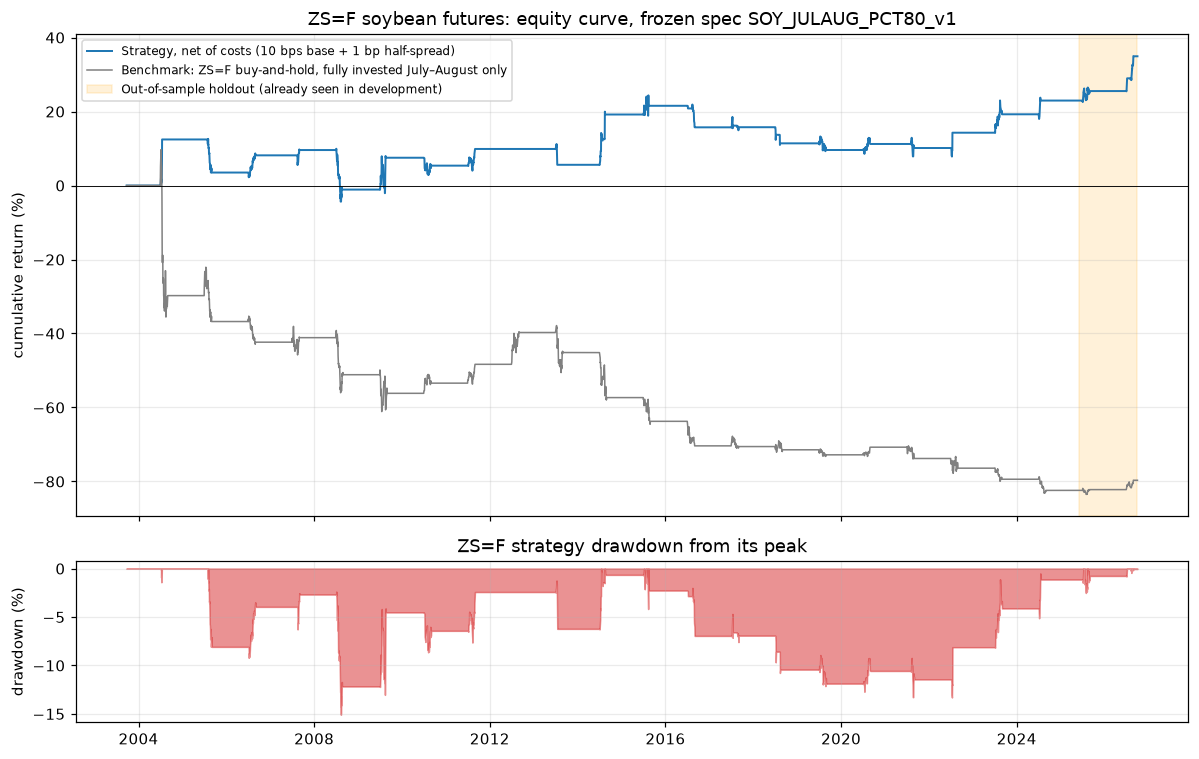

In [5]:
eps = episodes_detail(df)
bench_eq = np.cumprod(1 + df["px_ret"].values * df["in_season"].values) - 1
strat_eq = df["portfolio_value"] / s.INITIAL_CAPITAL - 1
peak = df["portfolio_value"].cummax()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
a1.plot(df.index, strat_eq * 100, lw=1.3, color="#1f77b4",
        label="Strategy, net of costs (10 bps base + 1 bp half-spread)")
a1.plot(df.index, bench_eq * 100, lw=1.0, color="gray",
        label=f"Benchmark: {TICKER} buy-and-hold, fully invested July–August only")
a1.axvspan(HOLD_START, df.index[-1], color="orange", alpha=0.15,
           label="Out-of-sample holdout (already seen in development)")
a1.axhline(0, color="black", lw=0.6)
a1.set_ylabel("cumulative return (%)")
a1.set_title(f"{TICKER} soybean futures: equity curve, frozen spec SOY_JULAUG_PCT80_v1")
a1.legend(loc="upper left", fontsize=8)
a2.fill_between(df.index, (df["portfolio_value"] / peak - 1) * 100, 0, color="#d62728", alpha=0.5)
a2.set_ylabel("drawdown (%)")
a2.set_title(f"{TICKER} strategy drawdown from its peak")
fig.tight_layout()
plt.show()

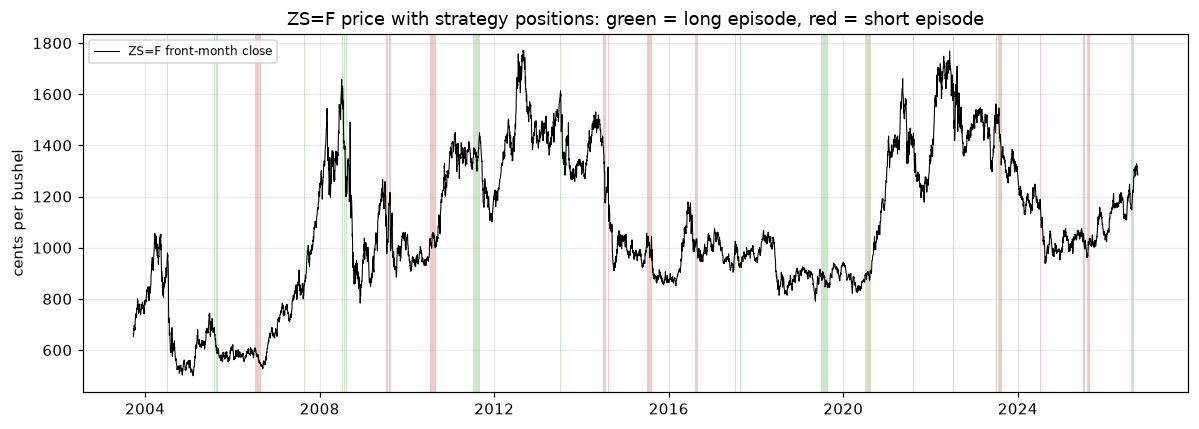

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
c = close.loc[df.index[0]:df.index[-1]]
ax.plot(c.index, c.values, color="black", lw=0.7, label=f"{TICKER} front-month close")
for _, e in eps.iterrows():
    ax.axvspan(e["entry"], e["exit"], color="#2ca02c" if e["side"] == "long" else "#d62728", alpha=0.25, lw=0)
ax.set_ylabel("cents per bushel")
ax.set_title(f"{TICKER} price with strategy positions: green = long episode, red = short episode")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

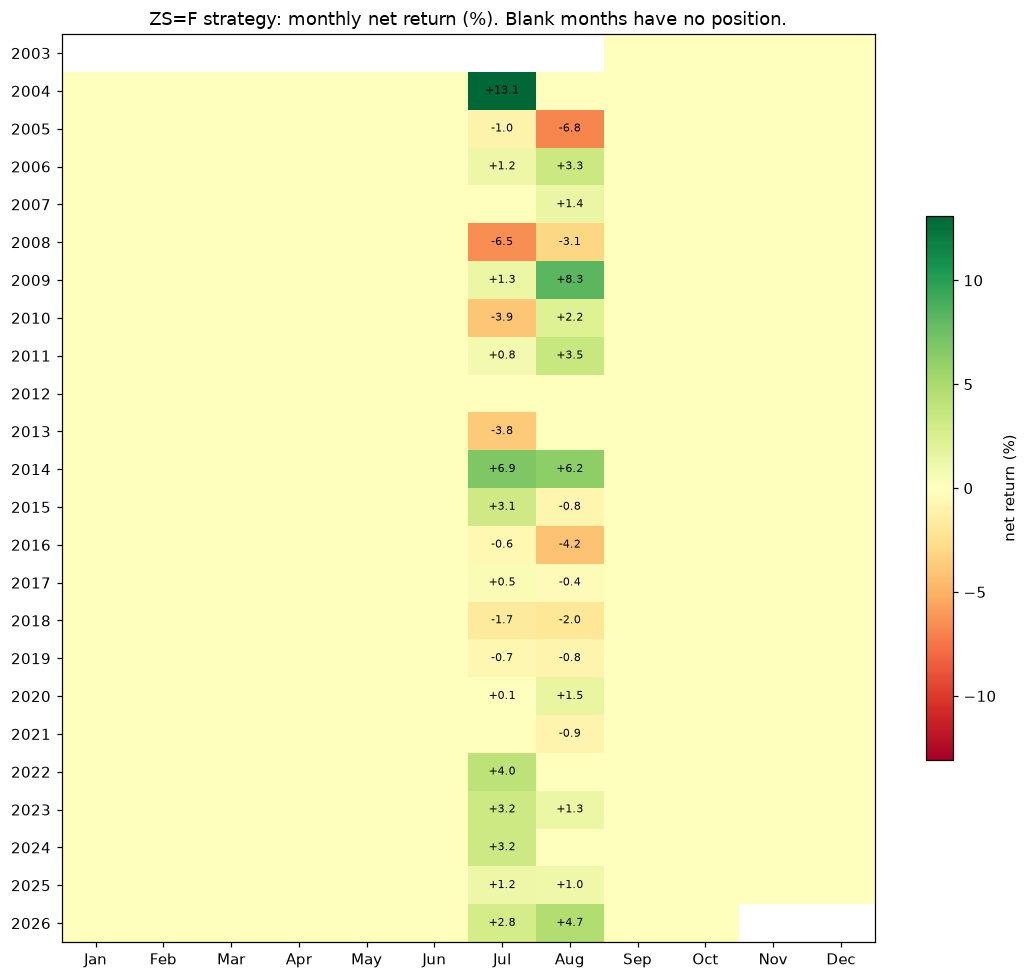

In [7]:
monthly = (1 + df["net_ret"]).groupby([df.index.year, df.index.month]).prod() - 1
mt = monthly.unstack()
mt.columns = [pd.Timestamp(2000, m, 1).strftime("%b") for m in mt.columns]
vmax = np.nanmax(np.abs(mt.values)) * 100
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(mt.values * 100, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(mt.shape[1])); ax.set_xticklabels(mt.columns)
ax.set_yticks(range(mt.shape[0])); ax.set_yticklabels(mt.index)
for i in range(mt.shape[0]):
    for j in range(mt.shape[1]):
        v = mt.values[i, j]
        if abs(v) > 1e-9:
            ax.text(j, i, f"{v*100:+.1f}", ha="center", va="center", fontsize=7)
ax.grid(False)
ax.set_title(f"{TICKER} strategy: monthly net return (%). Blank months have no position.")
fig.colorbar(im, ax=ax, label="net return (%)", shrink=0.6)
fig.tight_layout()
plt.show()

In [8]:
eps_show = eps.copy()
eps_show["net P&L (% of starting capital)"] = eps_show["net_pnl_usd"] / s.INITIAL_CAPITAL * 100
eps_show["entry"] = eps_show["entry"].dt.date
eps_show["exit"] = eps_show["exit"].dt.date
print(f"{len(eps_show)} episodes on {TICKER}, full history. Last 10 shown below.")
eps_show.tail(10)[["side", "entry", "exit", "days_held", "net_pnl_usd", "net P&L (% of starting capital)"]]

67 episodes on ZS=F, full history. Last 10 shown below.


,side,entry,exit,days_held,net_pnl_usd,net P&L (% of starting capital)
57,short,2025-07-02,2025-07-18,12,12231.967717,1.223197
58,long,2025-07-21,2025-07-25,5,-3683.536871,-0.368354
59,short,2025-07-29,2025-08-04,5,7253.477329,0.725348
60,long,2025-08-05,2025-08-11,5,11771.847768,1.177185
61,short,2025-08-12,2025-08-20,7,10375.281215,1.037528
62,short,2025-08-22,2025-08-25,2,5931.819033,0.593182
63,long,2025-08-26,2025-08-29,4,1497.764591,0.149776
64,long,2026-07-02,2026-07-06,2,27301.526287,2.730153
65,long,2026-08-04,2026-08-19,12,36489.054706,3.648905
66,long,2026-08-25,2026-08-31,5,24620.360062,2.462036


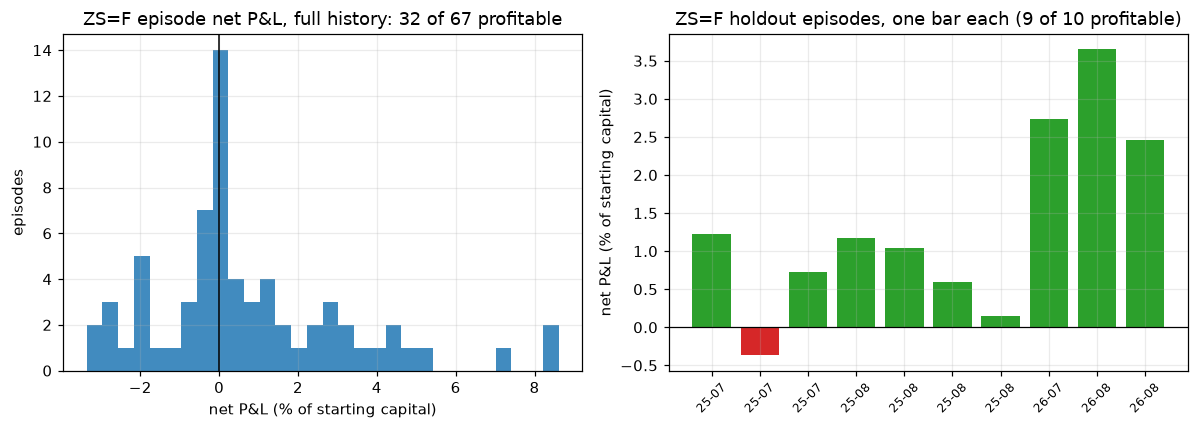

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.hist(eps["net_pnl_usd"] / s.INITIAL_CAPITAL * 100, bins=30, color="#1f77b4", alpha=0.85)
a1.axvline(0, color="black", lw=1)
wins = int((eps["net_pnl_usd"] > 0).sum())
a1.set_title(f"{TICKER} episode net P&L, full history: {wins} of {len(eps)} profitable")
a1.set_xlabel("net P&L (% of starting capital)"); a1.set_ylabel("episodes")
ho = eps[eps["entry"] >= HOLD_START]
a2.bar(range(len(ho)), ho["net_pnl_usd"] / s.INITIAL_CAPITAL * 100,
       color=["#2ca02c" if v > 0 else "#d62728" for v in ho["net_pnl_usd"]])
a2.axhline(0, color="black", lw=0.8)
a2.set_xticks(range(len(ho))); a2.set_xticklabels([d.strftime("%y-%m") for d in ho["entry"]], rotation=45, fontsize=8)
a2.set_title(f"{TICKER} holdout episodes, one bar each ({int((ho['net_pnl_usd'] > 0).sum())} of {len(ho)} profitable)")
a2.set_ylabel("net P&L (% of starting capital)")
fig.tight_layout()
plt.show()

## 8. Costs: basis points per trade and why we use them

**The cost the engine charges.** Each unit of position change is charged **11 bps of equity**, made up of:

- **10 bps base** (`TRANSACTION_COST_BPS`): the spec's base case. It is a single allowance for commission, impact, slippage and roll.
- **1 bp half-spread** (`EXECUTION_ASSUMPTIONS`): half a one-tick quoted spread.

**What that means per trade.** A 50% position that is opened and then closed is 0.5 + 0.5 = 1.0 unit traded, so it costs 11 bps of equity for the episode. A stop-loss exit followed by a re-entry costs again, which is why the cost per episode is slightly above 11 bps.

**An audit finding.** Not every position change is charged. The season-end exits on the first day after the trading window (1 September) close the position without a cost, and that day's price move is not booked. Section 8.1 measures the effect. Because of this, the *effective* cost across all trades is 10.0 bps, not 11.

The next cells check the charged rate, measure the uncharged exits, and justify the rate against real contract economics.

In [10]:
prev_pv = df["portfolio_value"].shift(1)
charged = (df["traded"] > 0) & (df["transaction_costs"] > 0)
uncharged = (df["traded"] > 0) & (df["transaction_costs"] == 0)
implied_bps = df.loc[charged, "transaction_costs"] / (prev_pv[charged] * df.loc[charged, "traded"]) * 1e4
print(f"Charged position changes: {charged.sum()}   rate per unit traded: median {implied_bps.median():.2f} bps "
      f"(min {implied_bps.min():.2f}, max {implied_bps.max():.2f})")
print(f"  engine setting: {s.TRANSACTION_COST_BPS:.0f} bps base + {half_spread:.0f} bp half-spread = {s.TRANSACTION_COST_BPS + half_spread:.0f} bps")
print(f"Position changes with NO cost: {uncharged.sum()}  (see audit below)")

Charged position changes: 107   rate per unit traded: median 11.00 bps (min 11.00, max 11.00)
  engine setting: 10 bps base + 1 bp half-spread = 11 bps
Position changes with NO cost: 12  (see audit below)


### 8.1 Audit: position changes the engine did not charge

The engine's flat-day branch (`if not active_commodities:` in `soyweather/simulation.py`) records the first off-season day with `transaction_costs = 0` and skips the season-exit cost code. A soybeans-only run therefore closes its position on 1 September for free, and that day's return is not booked. The cell below measures this. The engine is not changed here, because the frozen reference and every verdict depend on it.

In [11]:
gap = df[uncharged].copy()
gap["missing cost ($)"] = gap["traded"] * prev_pv[uncharged] * (s.TRANSACTION_COST_BPS + half_spread) / 1e4
gap["price P&L not booked ($, approx)"] = gap["pos_prev"] * gap["px_ret"] * prev_pv[uncharged]
gap_show = gap.reset_index()[["date", "pos_prev", "pos", "missing cost ($)", "price P&L not booked ($, approx)"]]
gap_show["date"] = gap_show["date"].dt.date
print(f"Uncharged exits: {len(gap)} (full history), {int((gap.index >= HOLD_START).sum())} of them in the holdout.")
print(f"Missing cost: ${gap['missing cost ($)'].sum():,.0f} full history, ${gap.loc[gap.index >= HOLD_START, 'missing cost ($)'].sum():,.0f} holdout.")
print(f"Price P&L not booked on those days: ${gap['price P&L not booked ($, approx)'].sum():,.0f} full history.")

# First-order correction: charge the missing cost and book the skipped day's P&L. Not a new run; an estimate.
corr_ret = df["net_ret"].copy()
adj = (gap["price P&L not booked ($, approx)"] - gap["missing cost ($)"]) / prev_pv[uncharged]
corr_ret.loc[gap.index] = corr_ret.loc[gap.index] + adj
sh = lambda x: x.mean() / x.std(ddof=1) * np.sqrt(252)
is_oos = df.index >= HOLD_START
audit = pd.DataFrame({
    "Engine (as saved)": [sh(df["net_ret"]), sh(df.loc[is_oos, "net_ret"])],
    "First-order correction": [sh(corr_ret), sh(corr_ret[is_oos])],
}, index=["Full history Sharpe", "Holdout Sharpe"])
print("Effect on Sharpe (first-order estimate, not a new engine run):")
audit

Uncharged exits: 12 (full history), 2 of them in the holdout.
Missing cost: $7,527 full history, $1,433 holdout.
Price P&L not booked on those days: $29,786 full history.
Effect on Sharpe (first-order estimate, not a new engine run):


,Engine (as saved),First-order correction
Full history Sharpe,0.347120,0.362954
Holdout Sharpe,1.809123,1.848023


In [12]:
# Justify the cost against contract economics at the holdout's average price.
hold_price = close.loc[HOLD_START:].mean()           # cents per bushel
CONTRACT_BU = 5000                                    # CME soybean contract size
notional = CONTRACT_BU * hold_price / 100            # $ per contract at that price
COMMISSION_PER_CONTRACT = 2.0                         # ASSUMPTION: $ per contract per side. Check your broker's schedule.

commission_bps = COMMISSION_PER_CONTRACT / notional * 1e4
half_tick_bps = 0.125 / hold_price * 1e4
observable_bps = commission_bps + half_tick_bps
engine_bps = float(s.TRANSACTION_COST_BPS + half_spread)

cost_stack = pd.DataFrame([
    ["Commission and exchange/clearing fees (assumed)", commission_bps, "Assumption; varies by broker and account type"],
    ["Half of a one-tick quoted spread (¼ ¢/bu)", half_tick_bps, "A one-tick-wide spread in a liquid front month"],
    ["Observable cost: commission + half-spread", observable_bps, "Lower bound for a liquid, one-lot trade at the close"],
    ["Engine base cost (TRANSACTION_COST_BPS)", float(s.TRANSACTION_COST_BPS), "Allowance for impact, slippage, roll and fills at the close"],
    ["Engine all-in cost (base + half-spread)", engine_bps, "Used in every result"],
], columns=["Component", "bps", "Basis"])
print(f"Holdout average {TICKER} price: {hold_price:,.0f} cents/bu. One contract ≈ ${notional:,.0f} notional.")
print(f"One tick (¼ ¢/bu) = ${0.25 * CONTRACT_BU / 100:.2f} per contract.")
print(f"Engine all-in cost is {engine_bps / observable_bps:.1f}x the observable commission + half-spread stack.")
cost_stack

Holdout average ZS=F price: 1,116 cents/bu. One contract ≈ $55,805 notional.
One tick (¼ ¢/bu) = $12.50 per contract.
Engine all-in cost is 7.4x the observable commission + half-spread stack.


,Component,bps,Basis
0,Commission and exchange/clearing fees (assumed),0.358388,Assumption; varies by broker and account type
1,Half of a one-tick quoted spread (¼ ¢/bu),1.119963,A one-tick-wide spread in a liquid front month
2,Observable cost: commission + half-spread,1.478351,"Lower bound for a liquid, one-lot trade at the..."
3,Engine base cost (TRANSACTION_COST_BPS),10.000000,"Allowance for impact, slippage, roll and fills..."
4,Engine all-in cost (base + half-spread),11.000000,Used in every result


**Justification.**

- **The 1 bp half-spread is about right.** The minimum tick on `ZS=F` is ¼ cent per bushel. At the holdout's price, one tick is about 2 bps of price. A half-tick is therefore about 1 bp, which matches a one-tick-wide quoted spread in a liquid front month.
- **The commission estimate is small.** A few dollars per contract is well under 1 bp of notional. The exact figure depends on the broker and is an assumption here.
- **The 10 bps base is deliberately larger than the spread and commission stack.** The engine fills at closing prices, and it does not model market impact, slippage, or the cost of rolling from one contract month to the next. The 10 bps is the allowance for those costs. The ratio printed above shows how many times larger the all-in cost is than the observable stack.
- **The base is a judgement, and the sweep shows how much it matters.** The spec does not derive 10 bps from data. It is a stated assumption, and it is tested at 25 and 50 bps.
- **Stress tests.** The spec asks for 25 and 50 bps. Section 8.2 runs them.

### 8.2 Cost sweep

The cost sweep runs the engine at 0, 10, 25 and 50 bps base. The 0 bps row still pays the 1 bp half-spread, so it is the closest the engine gets to gross.

In [13]:
SWEEP_CSV = ROOT / "soybean/results/inference/cost_sweep_v2.csv"
PERIOD_NAMES = {"full 2000-2026": "Full history", "holdout 2025-06 on": "Out-of-sample (holdout)"}

if MODE == "rerun":
    rows = []
    for bps in [0, 10, 25, 50]:
        eng.TRANSACTION_COST_BPS = float(bps)
        with contextlib.redirect_stdout(io.StringIO()):
            res = run_backtest(START, END, ["soybeans"], s.INITIAL_CAPITAL)
        dd_all = prepare(res, close)
        for name, (dd, base) in period_views(dd_all).items():
            if name == "In-sample":
                continue
            mm = performance(dd, base)
            rows.append({"cost_bps_base": bps, "period": name, "sharpe": mm["Sharpe (net, annualised)"],
                         "total_return": mm["Total return (value-based)"], "max_dd": mm["Max drawdown"],
                         "episodes": mm["Episodes (trades)"], "costs_usd": mm["Costs ($)"]})
    eng.TRANSACTION_COST_BPS = float(s.TRANSACTION_COST_BPS)
    sweep = pd.DataFrame(rows)
else:
    sweep = pd.read_csv(SWEEP_CSV).rename(columns={"sharpe_ann": "sharpe", "max_drawdown": "max_dd"})
    sweep["period"] = sweep["period"].map(PERIOD_NAMES)

sweep_fmt = sweep.assign(
    **{"Sharpe": sweep["sharpe"].map("{:+.2f}".format),
       "Total return": sweep["total_return"].map("{:+.1%}".format),
       "Max drawdown": sweep["max_dd"].map("{:.1%}".format),
       "Costs ($)": sweep["costs_usd"].map("${:,.0f}".format),
       "All-in bps": (sweep["cost_bps_base"] + half_spread).map("{:.0f}".format)})
sweep_fmt[["period", "cost_bps_base", "All-in bps", "Sharpe", "Total return", "Max drawdown", "episodes", "Costs ($)"]] \
    .rename(columns={"period": "Period", "cost_bps_base": "Base bps", "episodes": "Episodes"})

,Period,Base bps,All-in bps,Sharpe,Total return,Max drawdown,Episodes,Costs ($)
0,Full history,0,1,+0.40,+43.4%,-14.4%,67,"$7,116"
1,Out-of-sample (holdout),0,1,+1.97,+10.7%,-2.3%,10,"$1,198"
2,Full history,10,11,+0.35,+34.9%,-15.1%,67,"$75,854"
3,Out-of-sample (holdout),10,11,+1.81,+9.7%,-2.5%,10,"$12,461"
4,Full history,25,26,+0.26,+23.1%,-16.1%,67,"$171,137"
5,Out-of-sample (holdout),25,26,+1.55,+8.3%,-2.8%,10,"$27,067"
6,Full history,50,51,+0.12,+5.6%,-20.0%,67,"$311,095"
7,Out-of-sample (holdout),50,51,+1.11,+5.9%,-3.5%,10,"$46,114"


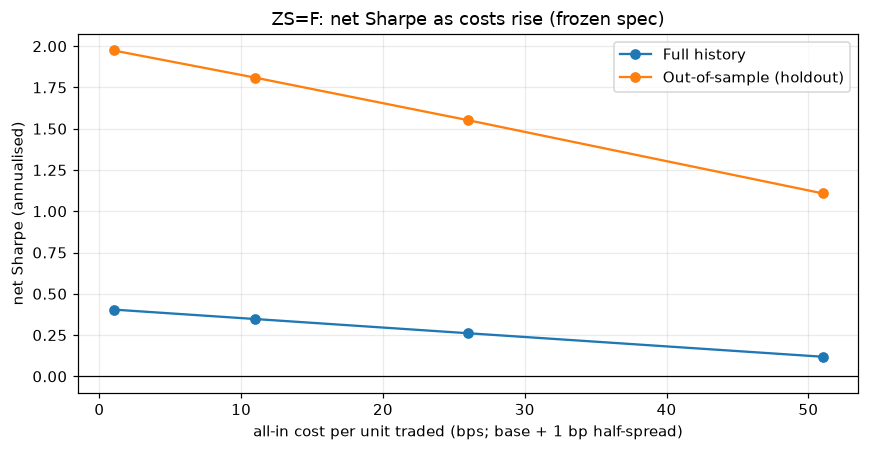

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for name, color in [("Full history", "#1f77b4"), ("Out-of-sample (holdout)", "#ff7f0e")]:
    sub = sweep[sweep["period"] == name].sort_values("cost_bps_base")
    ax.plot(sub["cost_bps_base"] + half_spread, sub["sharpe"], marker="o", color=color, label=name)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("all-in cost per unit traded (bps; base + 1 bp half-spread)")
ax.set_ylabel("net Sharpe (annualised)")
ax.set_title(f"{TICKER}: net Sharpe as costs rise (frozen spec)")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Statistical testing

Each test answers a specific question. The table in the results cell lists them in the same order.

| Test | Question it answers | Method |
|---|---|---|
| Sharpe and block-bootstrap 95% CI | How precise is the Sharpe? | Resample 21-session blocks (about one month), 5,000 draws, seed 0. Blocks keep the autocorrelation in returns. |
| Bootstrap p-value (one-sided) | Could a Sharpe this large arise if the true Sharpe were zero? | Recentre the returns to zero mean, resample, and count how often the resampled Sharpe reaches the observed one. |
| Probabilistic Sharpe ratio (PSR) | What is the probability the true Sharpe is above zero? | Bailey & López de Prado (2012). Adjusts for sample length, skew and kurtosis. |
| Deflated Sharpe ratio (DSR) | After trying 47 configurations, is the best Sharpe still impressive? | Bailey & López de Prado (2014). Raises the bar to the expected maximum Sharpe of 47 zero-skill trials. |
| Permutation test (gross) | Does the timing of positions beat random timing? | Circularly shift the position series against the returns 5,000 times. Gross of costs, so it isolates timing. |
| Win rate: Wilson CI and exact binomial | Is the share of winning episodes different from 50%? | Wilson (1927) interval; two-sided exact binomial test. |
| Sharpe vs Jul–Aug buy-and-hold | Does the strategy beat simply holding `ZS=F` through the same months? | Paired block bootstrap of the Sharpe difference. |
| Forecast skill (Spearman) | Does the forecast rank the 10-session outcomes correctly? | Spearman correlation on in-sample forecasts, 2005 to 2025-05. |

The bootstrap and permutation counts are fixed (5,000 draws, seed 0) so the notebook reproduces the saved statistics exactly.

In [15]:
def sharpe_daily(r):
    return r.mean() / r.std(ddof=1)


def psr(sr, T, skew, kurt, bench=0.0):
    """Probabilistic Sharpe ratio (Bailey & López de Prado, 2012). sr is per period; kurt is raw kurtosis."""
    denom = np.sqrt(1 - skew * sr + (kurt - 1) / 4 * sr ** 2)
    return stats.norm.cdf((sr - bench) * np.sqrt(T - 1) / denom)


def dsr(sr, T, skew, kurt, n_trials):
    """Deflated Sharpe ratio: PSR against the expected maximum Sharpe of n_trials zero-skill configurations."""
    var_trials = 1.0 / T
    sr_star = np.sqrt(var_trials) * ((1 - EULER_GAMMA) * stats.norm.ppf(1 - 1 / n_trials)
                                     + EULER_GAMMA * stats.norm.ppf(1 - 1 / (n_trials * np.e)))
    return psr(sr, T, skew, kurt, bench=sr_star), sr_star


def block_bootstrap_sharpes(r, seed=SEED, draws=DRAWS):
    rng = np.random.default_rng(seed)
    n = len(r)
    nb = int(np.ceil(n / BLOCK))
    out = np.empty(draws)
    for k in range(draws):
        starts = rng.integers(0, n - BLOCK + 1, size=nb)
        sample = np.concatenate([r[st:st + BLOCK] for st in starts])[:n]
        sd = sample.std(ddof=1)
        out[k] = sample.mean() / sd * np.sqrt(252) if sd > 0 else np.nan
    return out


def paired_bootstrap_diff(a, b, seed=SEED, draws=DRAWS):
    rng = np.random.default_rng(seed)
    n = len(a)
    nb = int(np.ceil(n / BLOCK))
    diffs = np.empty(draws)
    for k in range(draws):
        starts = rng.integers(0, n - BLOCK + 1, size=nb)
        idx = np.concatenate([np.arange(st, st + BLOCK) for st in starts])[:n]
        sa, sb = a[idx], b[idx]
        va, vb = sa.std(ddof=1), sb.std(ddof=1)
        diffs[k] = (sa.mean() / va if va > 0 else np.nan) - (sb.mean() / vb if vb > 0 else np.nan)
    return diffs * np.sqrt(252)


def permutation_p(pos_prev, ret, observed, seed=SEED, perms=PERMS):
    rng = np.random.default_rng(seed)
    n = len(ret)
    null = np.empty(perms)
    for k in range(perms):
        shift = rng.integers(1, n)
        g = np.roll(pos_prev, shift) * ret
        null[k] = sharpe_daily(g) * np.sqrt(252) if g.std(ddof=1) > 0 else np.nan
    return float(np.nanmean(null >= observed)), null


def wilson(k, n, z=1.96):
    p = k / n
    den = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return centre - half, centre + half


def test_suite(d):
    net = d["net_ret"].values
    gross = (d["pos_prev"] * d["px_ret"]).values
    pos_prev, ret = d["pos_prev"].values, d["px_ret"].values
    bench = (d["px_ret"] * d["in_season"]).values
    T = len(net)
    sr_d = sharpe_daily(net)
    skew, kurt = float(stats.skew(net)), float(stats.kurtosis(net, fisher=False))
    p_dsr, sr_star = dsr(sr_d, T, skew, kurt, N_TRIALS)
    boot = block_bootstrap_sharpes(net)
    boot_null = block_bootstrap_sharpes(net - net.mean(), seed=SEED + 1)
    obs_gross = sharpe_daily(gross) * np.sqrt(252)
    p_perm, perm_null = permutation_p(pos_prev, ret, obs_gross)
    diff = paired_bootstrap_diff(net, bench)
    ep = episodes_detail(d)
    k, n_ep = int((ep["net_pnl_usd"] > 0).sum()), len(ep)
    w_lo, w_hi = wilson(k, n_ep)
    bench_sr = sharpe_daily(bench) * np.sqrt(252)
    out = {
        "Sharpe (net, annualised)": sr_d * np.sqrt(252),
        "Bootstrap 95% CI, low": np.nanpercentile(boot, 2.5),
        "Bootstrap 95% CI, high": np.nanpercentile(boot, 97.5),
        "Bootstrap p-value, H0: Sharpe ≤ 0": float(np.nanmean(boot_null >= sr_d * np.sqrt(252))),
        "Probabilistic Sharpe, P(true Sharpe > 0)": float(psr(sr_d, T, skew, kurt)),
        f"Deflated Sharpe (N = {N_TRIALS} trials)": float(p_dsr),
        "Gross Sharpe (before costs)": obs_gross,
        "Permutation p-value, gross Sharpe": p_perm,
        "Episodes": n_ep,
        "Winning episodes": k,
        "Win rate": k / n_ep,
        "Win rate, Wilson 95% low": w_lo,
        "Win rate, Wilson 95% high": w_hi,
        "Win rate, exact binomial p vs 50%": float(stats.binomtest(k, n_ep, 0.5).pvalue),
        "Benchmark Sharpe (Jul–Aug buy-and-hold)": bench_sr,
        "Sharpe minus benchmark": sr_d * np.sqrt(252) - bench_sr,
        "Sharpe minus benchmark, 95% CI low": np.nanpercentile(diff, 2.5),
        "Sharpe minus benchmark, 95% CI high": np.nanpercentile(diff, 97.5),
        "Sharpe minus benchmark, one-sided p": float(np.nanmean(diff <= 0)),
        "Skewness (daily net return)": skew,
        "Excess kurtosis (daily net return)": kurt - 3,
    }
    arrays = {"boot": boot, "boot_null": boot_null, "perm_null": perm_null, "obs_gross": obs_gross}
    return out, arrays


STATS, ARR = {}, {}
for name, (dd, _) in period_views(df).items():
    STATS[name], ARR[name] = test_suite(dd)
stat_table = pd.DataFrame(STATS)
print(f"Statistical tests on {TICKER}, net of costs. 5,000 bootstrap and permutation draws, seed 0.")
stat_table.style.format("{:.4f}")

Statistical tests on ZS=F, net of costs. 5,000 bootstrap and permutation draws, seed 0.


,Full history,In-sample,Out-of-sample (holdout)
"Sharpe (net, annualised)",0.3471,0.2714,1.8091
"Bootstrap 95% CI, low",-0.0965,-0.1821,0.5025
"Bootstrap 95% CI, high",0.7414,0.6811,3.2032
"Bootstrap p-value, H0: Sharpe ≤ 0",0.0564,0.1224,0.0158
"Probabilistic Sharpe, P(true Sharpe > 0)",0.9611,0.9071,0.9937
Deflated Sharpe (N = 47 trials),0.2666,0.1499,0.4226
Gross Sharpe (before costs),0.3922,0.3036,2.0180
"Permutation p-value, gross Sharpe",0.0278,0.0774,0.0226
Episodes,67.0000,57.0000,10.0000
Winning episodes,32.0000,23.0000,9.0000


### 9.1 Reconciliation with the saved statistics

The saved statistics are in `soybean/results/inference/inference_summary.json`, from `soybean/experiments/inference_suite.py`. The next cell checks that this notebook's code reproduces them. In `saved` mode the numbers should match exactly. In `rerun` mode small differences are expected if the market or climate data has changed since the saved run.

In [16]:
import json
saved = json.loads((ROOT / "soybean/results/inference/inference_summary.json").read_text())
DSR_KEY = f"Deflated Sharpe (N = {N_TRIALS} trials)"
# (notebook key, getter from the saved JSON)
pairs = [
    ("Sharpe (net, annualised)", lambda j: j["sharpe_ann"]),
    ("Bootstrap 95% CI, low", lambda j: j["bootstrap_ci95_ann"][0]),
    ("Bootstrap 95% CI, high", lambda j: j["bootstrap_ci95_ann"][1]),
    ("Bootstrap p-value, H0: Sharpe ≤ 0", lambda j: j["bootstrap_p_one_sided"]),
    ("Probabilistic Sharpe, P(true Sharpe > 0)", lambda j: j["psr_vs_zero"]),
    (DSR_KEY, lambda j: j["dsr"]),
    ("Gross Sharpe (before costs)", lambda j: j["gross_sharpe_ann"]),
    ("Permutation p-value, gross Sharpe", lambda j: j["permutation_p_gross"]),
    ("Episodes", lambda j: j["episodes"]),
    ("Winning episodes", lambda j: j["wins"]),
    ("Win rate, Wilson 95% low", lambda j: j["win_rate_wilson95"][0]),
    ("Win rate, Wilson 95% high", lambda j: j["win_rate_wilson95"][1]),
    ("Win rate, exact binomial p vs 50%", lambda j: j["win_rate_binomial_p_two_sided"]),
    ("Skewness (daily net return)", lambda j: j["skew"]),
    ("Excess kurtosis (daily net return)", lambda j: j["excess_kurtosis"]),
]
rec = []
for key, get in pairs:
    mine_f = STATS["Full history"][key]
    mine_o = STATS["Out-of-sample (holdout)"][key]
    s_f, s_o = get(saved["full"]), get(saved["holdout"])
    rec.append({"Statistic": key, "Full: notebook": mine_f, "Full: saved": s_f,
                "OOS: notebook": mine_o, "OOS: saved": s_o,
                "Match": abs(mine_f - s_f) < 1e-6 and abs(mine_o - s_o) < 1e-6})
# Benchmark CI from the paired bootstrap (full history and holdout)
for key, sk_, per in [("Sharpe minus benchmark, 95% CI low", 0, "full"), ("Sharpe minus benchmark, 95% CI high", 1, "full")]:
    mine_f = STATS["Full history"][key]
    s_f = saved["vs_inseason_buy_hold"]["full"]["diff_ci95"][sk_]
    mine_o = STATS["Out-of-sample (holdout)"][key]
    s_o = saved["vs_inseason_buy_hold"]["holdout"]["diff_ci95"][sk_]
    rec.append({"Statistic": key, "Full: notebook": mine_f, "Full: saved": s_f,
                "OOS: notebook": mine_o, "OOS: saved": s_o,
                "Match": abs(mine_f - s_f) < 1e-6 and abs(mine_o - s_o) < 1e-6})
rec = pd.DataFrame(rec)
ok = rec["Match"].all()
print("All statistics reproduce the saved numbers." if ok else "Some statistics differ from the saved numbers (see Match column).")
rec

All statistics reproduce the saved numbers.


,Statistic,Full: notebook,Full: saved,OOS: notebook,OOS: saved,Match
0,"Sharpe (net, annualised)",0.347120,0.347120,1.809123,1.809123,True
1,"Bootstrap 95% CI, low",-0.096507,-0.096507,0.502458,0.502458,True
2,"Bootstrap 95% CI, high",0.741381,0.741381,3.203151,3.203151,True
3,"Bootstrap p-value, H0: Sharpe ≤ 0",0.056400,0.056400,0.015800,0.015800,True
4,"Probabilistic Sharpe, P(true Sharpe > 0)",0.961087,0.961087,0.993669,0.993669,True
5,Deflated Sharpe (N = 47 trials),0.266632,0.266632,0.422646,0.422646,True
6,Gross Sharpe (before costs),0.392153,0.392153,2.017980,2.017980,True
7,"Permutation p-value, gross Sharpe",0.027800,0.027800,0.022600,0.022600,True
8,Episodes,67.000000,67.000000,10.000000,10.000000,True
9,Winning episodes,32.000000,32.000000,9.000000,9.000000,True


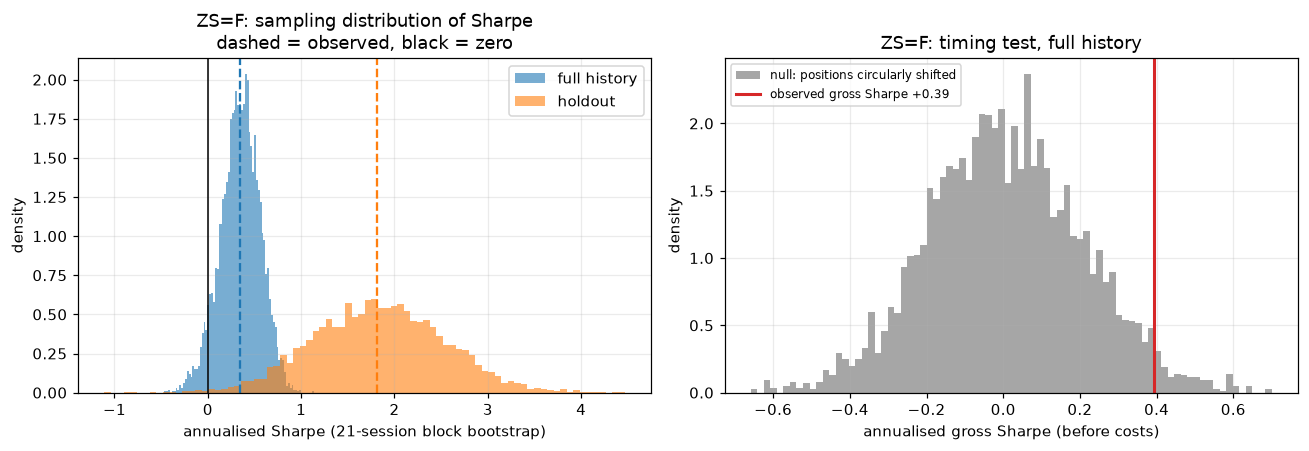

In [17]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
bf = ARR["Full history"]["boot"]; bh = ARR["Out-of-sample (holdout)"]["boot"]
a1.hist(bf[~np.isnan(bf)], bins=80, alpha=0.6, density=True, label="full history")
a1.hist(bh[~np.isnan(bh)], bins=80, alpha=0.6, density=True, label="holdout")
a1.axvline(0, color="black", lw=1)
a1.axvline(STATS["Full history"]["Sharpe (net, annualised)"], color="#1f77b4", ls="--", lw=1.5)
a1.axvline(STATS["Out-of-sample (holdout)"]["Sharpe (net, annualised)"], color="#ff7f0e", ls="--", lw=1.5)
a1.set_xlabel("annualised Sharpe (21-session block bootstrap)"); a1.set_ylabel("density")
a1.set_title(f"{TICKER}: sampling distribution of Sharpe\ndashed = observed, black = zero"); a1.legend()
pn = ARR["Full history"]["perm_null"]
a2.hist(pn[~np.isnan(pn)], bins=80, color="gray", alpha=0.7, density=True, label="null: positions circularly shifted")
a2.axvline(ARR["Full history"]["obs_gross"], color="#d62728", lw=2,
           label=f"observed gross Sharpe {ARR['Full history']['obs_gross']:+.2f}")
a2.set_xlabel("annualised gross Sharpe (before costs)"); a2.set_ylabel("density")
a2.set_title(f"{TICKER}: timing test, full history"); a2.legend(fontsize=8)
fig.tight_layout()
plt.show()

Forecast skill, in-sample (860 forecasts): Spearman -0.044 (p = 0.20), sign hit rate 52.9%
A positive Spearman with p < 0.05 would indicate the forecast ranks outcomes correctly. Here it does not.


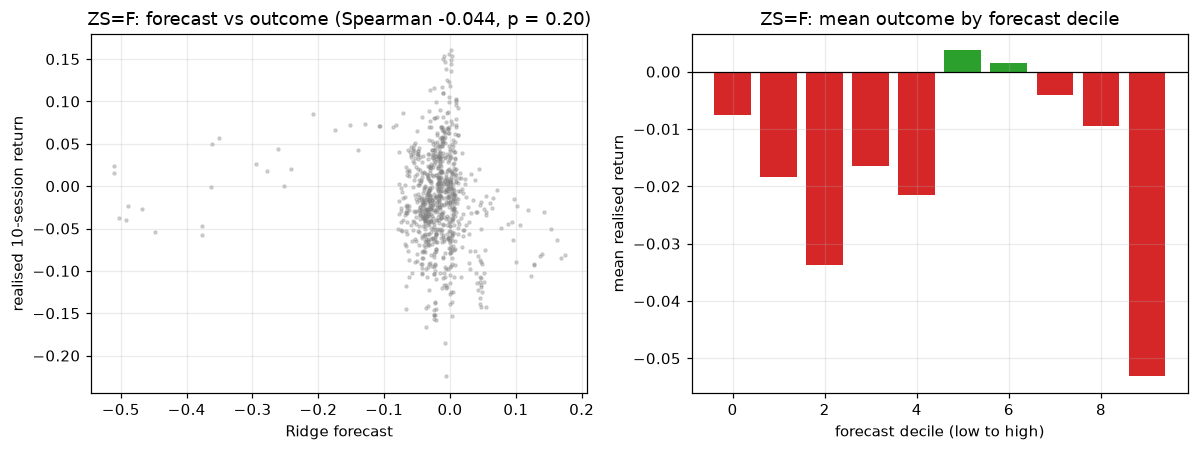

In [18]:
sk = pd.read_csv(ROOT / "soybean/results/skill_predictions.csv", parse_dates=["date"])
dev = sk[(sk["date"] >= "2005-01-01") & (sk["date"] < HOLD_START)].copy()
rho, rho_p = stats.spearmanr(dev["pred"], dev["fwd"])
hit = (np.sign(dev["pred"]) == np.sign(dev["fwd"])).mean()
print(f"Forecast skill, in-sample ({len(dev)} forecasts): Spearman {rho:+.3f} (p = {rho_p:.2f}), sign hit rate {hit:.1%}")
print("A positive Spearman with p < 0.05 would indicate the forecast ranks outcomes correctly. Here it does not.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.scatter(dev["pred"], dev["fwd"], s=4, alpha=0.3, color="gray")
a1.set_xlabel("Ridge forecast"); a1.set_ylabel("realised 10-session return")
a1.set_title(f"{TICKER}: forecast vs outcome (Spearman {rho:+.3f}, p = {rho_p:.2f})")
bins = pd.qcut(dev["pred"], 10, duplicates="drop")
grp = dev.groupby(bins, observed=True)["fwd"].mean()
a2.bar(range(len(grp)), grp.values, color=["#2ca02c" if v > 0 else "#d62728" for v in grp.values])
a2.axhline(0, color="black", lw=0.8)
a2.set_xlabel("forecast decile (low to high)"); a2.set_ylabel("mean realised return")
a2.set_title(f"{TICKER}: mean outcome by forecast decile")
fig.tight_layout()
plt.show()

## 10. Parameter sensitivity (in-sample)

The spec has two main parameters: the volatility percentile filter and the stop-loss. The grid varies both over the in-sample period (2000 to 2025-05-31) and holds everything else fixed. It does not touch the holdout.

This is descriptive. It shows how sensitive the result is to those two choices. It does not pass or fail anything.

The stop-loss of 100% means "off". The engine cannot take a `None` stop, so 100% is used instead.

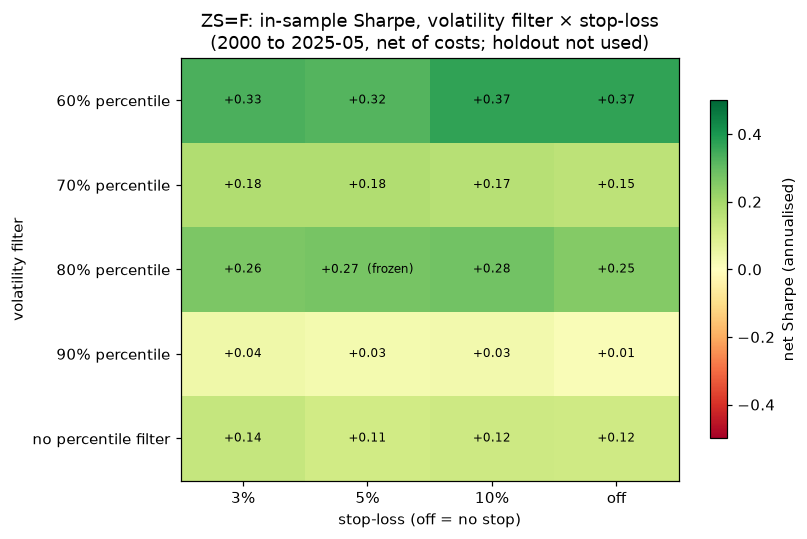

Cells with positive in-sample Sharpe: 20 of 20. Range +0.01 to +0.37.


In [19]:
GRID = ROOT / "soybean/results/inference/sensitivity_grid.csv"
VOL_LABELS = ["0.6", "0.7", "0.8", "0.9", "none"]
if MODE == "rerun" and RUN_SENSITIVITY:
    rows = []
    for vol in [0.6, 0.7, 0.8, 0.9, None]:
        for stop in [0.03, 0.05, 0.10, 1.0]:
            POSITION_FILTERS.update({"vol_percentile_hi": vol, "trend_sma": None, "stop_loss_pct": stop})
            with contextlib.redirect_stdout(io.StringIO()):
                res = run_backtest("2000-01-01", "2025-05-31", ["soybeans"], s.INITIAL_CAPITAL)
            dd = prepare(res, close)
            mm = performance(dd, s.INITIAL_CAPITAL)
            rows.append({"vol_percentile_hi": "none" if vol is None else str(vol), "stop_loss_pct": stop,
                         "sharpe": mm["Sharpe (net, annualised)"], "episodes": mm["Episodes (trades)"]})
    POSITION_FILTERS.update({"vol_percentile_hi": 0.80, "trend_sma": None, "stop_loss_pct": 0.05})
    grid = pd.DataFrame(rows)
else:
    grid = pd.read_csv(GRID)
    grid["vol_percentile_hi"] = grid["vol_percentile_hi"].astype(str)

piv = grid.pivot(index="vol_percentile_hi", columns="stop_loss_pct", values="sharpe").loc[VOL_LABELS]
fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=-0.5, vmax=0.5, aspect="auto")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels([f"{c:.0%}" if c < 1 else "off" for c in piv.columns])
ax.set_yticks(range(piv.shape[0]))
ax.set_yticklabels([("no percentile filter" if v == "none" else f"{float(v):.0%} percentile") for v in piv.index])
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        mark = "  (frozen)" if (piv.index[i] == "0.8" and piv.columns[j] == 0.05) else ""
        ax.text(j, i, f"{v:+.2f}{mark}", ha="center", va="center", fontsize=8)
ax.grid(False)
ax.set_xlabel("stop-loss (off = no stop)"); ax.set_ylabel("volatility filter")
ax.set_title(f"{TICKER}: in-sample Sharpe, volatility filter × stop-loss\n(2000 to 2025-05, net of costs; holdout not used)")
fig.colorbar(im, ax=ax, label="net Sharpe (annualised)", shrink=0.8)
fig.tight_layout()
plt.show()
print(f"Cells with positive in-sample Sharpe: {(grid['sharpe'] > 0).sum()} of {len(grid)}. Range {grid['sharpe'].min():+.2f} to {grid['sharpe'].max():+.2f}.")

## 11. Verdict and forward test

### 11.1 The pre-registered rule, applied to the saved run

The next cell applies the spec's rule to the holdout numbers. The v1 engine also failed the same rule on the same holdout, with 9 episodes against the 10 required.

In [20]:
h = sweep[sweep["period"] == "Out-of-sample (holdout)"].set_index("cost_bps_base")
rule = pd.DataFrame([
    ["Net Sharpe > 0 at 10 bps (holdout)", f"{h.loc[10, 'sharpe']:+.2f}", h.loc[10, "sharpe"] > 0],
    ["Max drawdown no worse than −25% (holdout, 10 bps)", f"{h.loc[10, 'max_dd']:.1%}", h.loc[10, "max_dd"] >= -0.25],
    ["At least 10 episodes (holdout, 10 bps)", f"{int(h.loc[10, 'episodes'])}", h.loc[10, "episodes"] >= 10],
    ["Robust: net Sharpe > 0 at 25 bps (holdout)", f"{h.loc[25, 'sharpe']:+.2f}", h.loc[25, "sharpe"] > 0],
], columns=["Condition", "Value", "Met"])
print("Numerical rule met on this run:", bool(rule["Met"].iloc[:3].all()), "| robust (25 bps) met:", bool(rule["Met"].iloc[3]))
rule

Numerical rule met on this run: True | robust (25 bps) met: True


,Condition,Value,Met
0,Net Sharpe > 0 at 10 bps (holdout),+1.81,True
1,"Max drawdown no worse than −25% (holdout, 10 bps)",-2.5%,True
2,"At least 10 episodes (holdout, 10 bps)",10,True
3,Robust: net Sharpe > 0 at 25 bps (holdout),+1.55,True


### 11.2 How to read the result

**The numerical rule is met on the saved run. That is not confirmation.** Four reasons:

1. **The holdout is spent.** The spec says the holdout "is the only test that counts", but it was used during development. The trial log records an earlier run on the same holdout (v1), which failed. A pass on v2 is therefore a second look at the same period.
2. **The engine changed between runs.** The v1 run failed with 9 episodes. The v2 run, after that result, has 10. Changing the engine after seeing a holdout result is a degree of freedom that the deflated Sharpe does not count.
2b. **The engine has a cost gap** (section 8.1). Season-end exits are not charged, and the first off-season day's P&L is not booked. The first-order correction moves the holdout Sharpe by about +0.04, so the gap does not change the verdict. It is still a bug in the record, and it should be fixed before the forward test is scored.
3. **The sample is tiny.** The holdout has 10 episodes, from two July–August seasons. The Sharpe's bootstrap interval runs from roughly +0.5 to +3.2.
4. **It does not clearly beat the simple benchmark.** Buying and holding `ZS=F` through July and August over the holdout has a Sharpe of +1.17, against the strategy's +1.81. The paired bootstrap difference is −0.78 to +2.21, with p = 0.21 (section 9).

**Full history is weaker.** Over all 67 episodes the Sharpe is +0.35, its interval includes zero, the deflated Sharpe is 0.27, and forecast rank skill is not significant. The timing result (permutation p = 0.028, gross) is the strongest evidence, and it is before costs.

**What would count.** The forward test in `soybean/spec/FORWARD_PROTOCOL.md`: run the frozen spec unchanged on the 2027 season (2027-07-01 to 2027-08-31), score it once, and keep it running for 2028 before drawing a conclusion. Any change to the rules creates a new spec with its own untouched window.

### 11.3 Governance note

The spec file says it was frozen before any holdout run. The trial log records holdout runs (v1 and v2), and the spec, the README and the trial log were all committed on 2026-10-04. Git history cannot show that the spec was written first. Read the spec as a statement of intent, not as a verified pre-registration.

## 12. Caveats and known limitations

- **Season-end cost gap.** On the first day after the trading window, the engine closes the position without charging the exit cost and without booking that day's price move (section 8.1). This affects 12 exits in the full history and 2 in the holdout. The first-order correction is small. The fix belongs in `simulation.py` and would change the frozen reference, so it has not been made.
- **Engine return definition.** The engine divides each day's P&L by *previous value minus today's P&L*, not by the previous value. Compounding its returns overstates the result. The full-history total is +41.7% on engine returns and +34.9% on portfolio value. The Sharpe effect is smaller (+0.35 falls to +0.31 on value-based returns). This notebook uses portfolio value for total return and drawdown, and engine returns for Sharpe and the tests, to match the saved statistics. The engine has not been changed, because doing so would move the frozen reference.
- **Holdout reuse.** See section 11.2.
- **Multiple testing.** About 47 configurations have been tried. Confidence intervals do not account for the search. The deflated Sharpe does, but it approximates the variance of the Sharpe as 1/T and treats the 47 trials as independent. For the general problem of multiple testing in return research, see Harvey, Liu & Zhu (2016).
- **Small samples.** The holdout is 10 episodes. The full history is 67 episodes, and win rate is 48% (Wilson 36% to 60%).
- **Costs decide the outcome.** The README (test S9) reports gross holdout return of about +8.2% before costs, and costs that consume 100 to 492 bps of starting capital at the 10 to 50 bps levels. The sweep in section 8.2 is the current record.
- **Execution.** Fills are at the closing price plus an assumed half-spread. There is no quote data, slippage model, queue position or margin-call model. The margin model is a simplification. Contract size and rounding are not modelled. A 50% position is treated as a fraction of equity, not a whole number of contracts.
- **Continuous futures.** `ZS=F` is an unadjusted front-month series. Roll dates create artificial price changes, and no adjustment has been made. Roll costs are not modelled explicitly, apart from the 10 bps allowance.
- **Weather data.** NASA POWER is a 0.5° gridded product, averaged across four states. It may not match individual fields.
- **Settings drift.** The `.env` file overrides the code defaults. The `.env` configuration gives different results (README section 11.2: holdout Sharpe +0.93 on fresh data). This notebook pins the code defaults, as the spec requires.
- **Live data.** NASA POWER and Yahoo data change over time, so a rerun can differ from the saved run.
- **Stop-loss.** `None` crashes the engine, so "off" is 100%.
- **Model.** `MODEL_TYPE=xgboost` does not run (the module is missing). `SIGNAL_CAP` is declared but not used. The GDD thresholds are declared but not used by the stress features.
- **Economic sign.** The model learns the direction of the weather effect. The economic story is a hypothesis about it, not an input to it.

## 13. References

**Methods**

- Bailey, D. H., & López de Prado, M. (2012). The Sharpe ratio efficient frontier. *Journal of Risk*, 15(2), 3–44.
- Bailey, D. H., & López de Prado, M. (2014). The deflated Sharpe ratio: Correcting for selection bias, backtest overfitting, and non-normality. *Journal of Portfolio Management*, 40(5), 94–107.
- Good, P. I. (2005). *Permutation, parametric and bootstrap tests of hypotheses* (3rd ed.). Springer.
- Künsch, H. R. (1989). The jackknife and the bootstrap for general stationary observations. *The Annals of Statistics*, 17(3), 1217–1241.
- Harvey, C. R., Liu, Y., & Zhu, H. (2016). ...and the cross-section of expected returns. *Review of Financial Studies*, 29(1), 5–68.
- Wilson, E. B. (1927). Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association*, 22(158), 209–212.

**Economic rationale and behavioural edge**

- Barber, B. M., & Odean, T. (2008). All that glitters: The effect of attention and news on the buying behavior of individual and institutional investors. *Review of Financial Studies*, 21(2), 785–818.
- Bessembinder, H. (1992). Systematic risk, hedging pressure, and risk premiums in futures markets. *Review of Financial Studies*, 5(4), 637–667.
- Hong, H., & Stein, J. C. (1999). A unified theory of underreaction, momentum trading, and overreaction in asset markets. *Journal of Finance*, 54(6), 2143–2184.
- Keynes, J. M. (1930). *A treatise on money, Vol. 2: The applied theory of money*. Macmillan.
- Roll, R. (1984). Orange juice and weather. *American Economic Review*, 74(5), 861–880.

**Data and market structure**

- Aroussi, R. *yfinance*: Python library for Yahoo Finance data. https://github.com/ranaroussi/yfinance
- CME Group. Soybean futures contract specifications (ZS). https://www.cmegroup.com/markets/agriculture/oilseeds/soybean.html
- NASA Langley Research Center. *Prediction Of Worldwide Energy Resources (POWER) Project*, Agroclimatology (AG) community. https://power.larc.nasa.gov/
- NOAA Climate Prediction Center. *Oceanic Niño Index (ONI)*. https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt
- USDA National Agricultural Statistics Service. *QuickStats*. https://quickstats.nass.usda.gov/

**Project documents**

- `soybean/spec/SOY_JULAUG_PCT80_v1.md`: the frozen spec.
- `soybean/spec/FORWARD_PROTOCOL.md`: the forward test.
- `soybean/spec/trial_log.md` and `trial_log.jsonl`: the record of configurations tried.
- `README.md`: the full write-up, including the experiment log.